In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

In [2]:
df = pd.read_csv("clean_streetlight_dataset (2).csv")

In [5]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

C:\Users\safda\AppData\Local\Temp\ipykernel_30212\966722803.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['timestamp'] = pd.to_datetime(df['timestamp'])


In [7]:
model1 = joblib.load("decision.pkl") # decision
model2 = joblib.load("svm.pkl")      #svm

In [9]:
X_model1 = df.drop(['fault_type', 'timestamp'], axis=1)

In [11]:
df['pred_decision'] = model1.predict(X_model1)

In [13]:
X_model2 = df.drop(['fault_type', 'timestamp', 'pred_decision'], axis=1)

In [15]:
df['pred_svm'] = model2.predict(X_model2)

In [17]:
def calculate_mttd(data, pred_col):

    faults = data[data['fault_type']==1]['timestamp'].reset_index(drop=True)
    detects = data[data[pred_col]==1]['timestamp'].reset_index(drop=True)

    n = min(len(faults), len(detects))

    faults = faults[:n]
    detects = detects[:n]

    mttd = (detects - faults).dt.total_seconds().mean()

    return mttd

In [27]:
mttd_decision = calculate_mttd(df,'pred_decision')
mttd_svm = calculate_mttd(df,'pred_svm')
print("MTTD Model 1:", mttd_decision)
print("MTTD Model 2:", mttd_svm)

MTTD Model 1: 7.898593200468933
MTTD Model 2: -932.3405627198124


In [31]:
models = ['pred_decision', 'pred_svm']
mttd_values = [mttd_decision, mttd_svm]

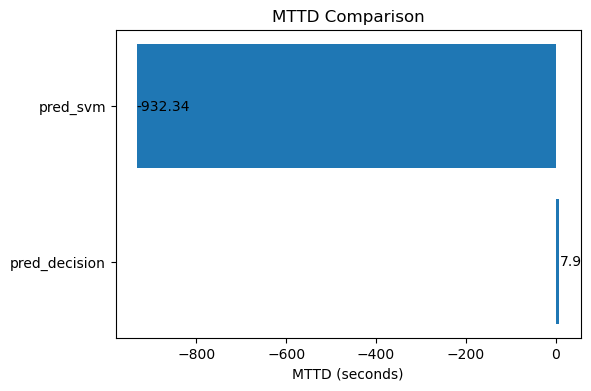

In [37]:
plt.figure(figsize=(6,4))

bars = plt.barh(models, mttd_values)

plt.xlabel("MTTD (seconds)")
plt.title("MTTD Comparison")

for bar in bars:
    width = bar.get_width()
    plt.text(width,
             bar.get_y() + bar.get_height()/2,
             round(width,2),
             va='center')

plt.show()

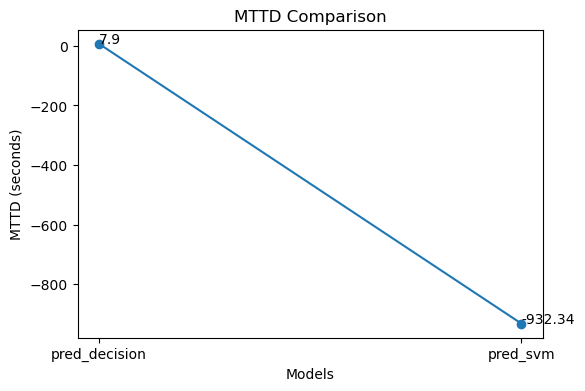

In [39]:
plt.figure(figsize=(6,4))

plt.plot(models, mttd_values, marker='o')

for i, value in enumerate(mttd_values):
    plt.text(models[i], value, round(value,2))

plt.title("MTTD Comparison")
plt.xlabel("Models")
plt.ylabel("MTTD (seconds)")

plt.show()

In [41]:
data = {'Model':['DecisionTree','SVM'],
        'MTTD':[mttd_decision,mttd_svm]}

df = pd.DataFrame(data)

df.to_csv("mttd_models2.csv",index=False)

In [43]:
df1 = pd.read_csv("mttd_models1.csv")
df2 = pd.read_csv("mttd_models2.csv")

df_all = pd.concat([df1,df2])

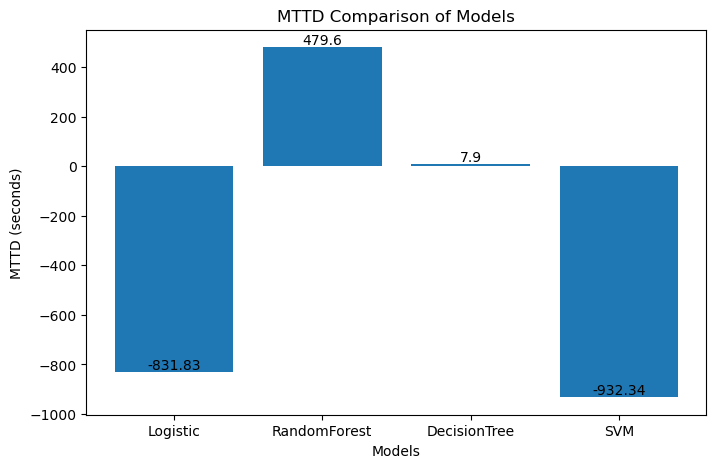

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(df_all['Model'], df_all['MTTD'])

plt.xlabel("Models")
plt.ylabel("MTTD (seconds)")
plt.title("MTTD Comparison of Models")

#value 
for bar in bars:
    value = bar.get_height()
    
    plt.text(bar.get_x() + bar.get_width()/2,
             value,
             round(value,2),
             ha='center',
             va='bottom')

plt.show()

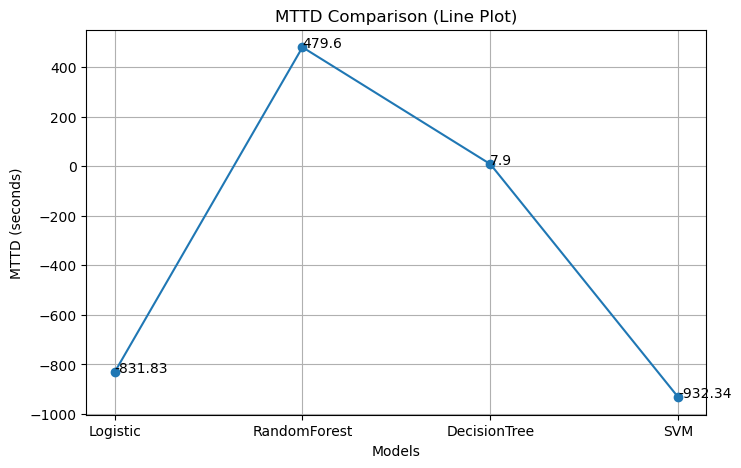

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(df_all['Model'], df_all['MTTD'], marker='o')

plt.xlabel("Models")
plt.ylabel("MTTD (seconds)")
plt.title("MTTD Comparison (Line Plot)")

# value
for i in range(len(df_all)):
    
    x = df_all['Model'].iloc[i]
    y = df_all['MTTD'].iloc[i]
    
    plt.text(x, y, round(y,2))

plt.grid(True)

plt.show()